## 6. Per-Person Confusion Matrix and Error Analysis

To examine which participants are most often confused with one another, cycle-level predictions were collected across the exhaustive trial-grouped evaluation.

The confusion matrices are normalized by the true participant, so each row shows the percentage of predictions assigned to each participant.

Because the exhaustive evaluation repeatedly tests the same held-out trials under different training-trial combinations, the values represent prediction behaviour across evaluation configurations rather than independent observations.

C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Project root : C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P
Feature file : C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P\results\cycle_features_with_quality.csv

Dataset shape: (435, 97)

Cycles by person:
person
Buddhini     77
Harshika     59
Muthuni      30
Nadeera     124
Thenuri     145
Name: count, dtype: int64

Number of model features: 91

Participants:
Buddhini  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(9)]
Harshika  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Muthuni   : [np.int64(1), np.int64(2), np.int64(3)]
Nadeera   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Thenuri   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Total exhaustive hold-out combinations: 1440

Loading saved Model A predictions...

Loading saved PCA predictions...

Model A predictions: 146712
Model B predictions: 146712

MODEL A — NORMALIZED CONFUSION MATRIX (%)
          Buddhini  Harshika  Muthuni  Nadeera  

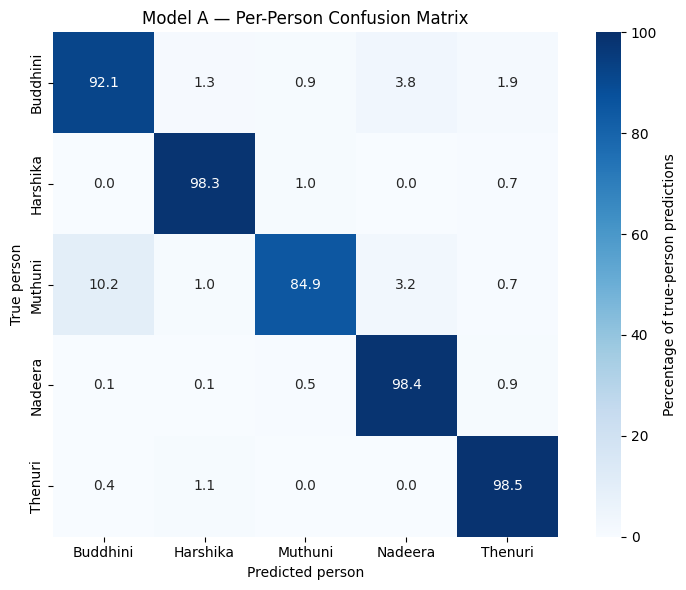


MODEL A — PER-PERSON PERFORMANCE
  person  precision_pct  identification_rate_pct  f1_pct  error_rate_pct
Buddhini          90.83                    92.15   91.48            7.85
Harshika          94.23                    98.31   96.22            1.69
 Muthuni          95.83                    84.85   90.01           15.15
 Nadeera          97.42                    98.36   97.89            1.64
 Thenuri          98.08                    98.48   98.28            1.52

MODEL A — CONFUSION PAIRS
  person predicted_person  repeated_errors  error_pct
 Muthuni         Buddhini             1471      10.22
Buddhini          Nadeera              696       3.77
 Muthuni          Nadeera              465       3.23
Buddhini          Thenuri              359       1.94
Buddhini         Harshika              238       1.29
 Thenuri         Harshika              597       1.14
Harshika          Muthuni              164       0.97
 Muthuni         Harshika              138       0.96
 Nadeera       

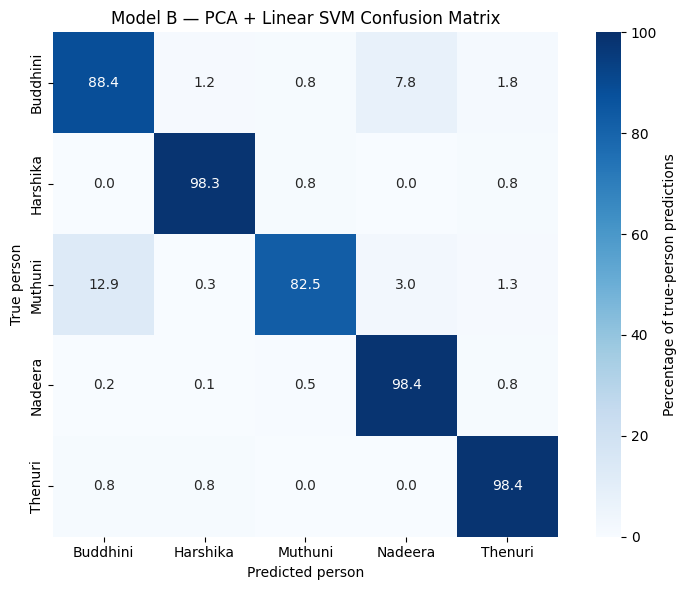


MODEL B — PER-PERSON PERFORMANCE
  person  precision_pct  identification_rate_pct  f1_pct  error_rate_pct
Buddhini          87.31                    88.41   87.86           11.59
Harshika          95.70                    98.31   96.99            1.69
 Muthuni          95.79                    82.45   88.62           17.55
 Nadeera          95.91                    98.38   97.13            1.62
 Thenuri          98.06                    98.36   98.21            1.64

PER-PERSON MODEL COMPARISON
  person  model_a_identification_pct  pca_identification_pct  change_after_pca_pp
Buddhini                       92.15                   88.41                -3.73
Harshika                       98.31                   98.31                 0.00
 Muthuni                       84.85                   82.45                -2.40
 Nadeera                       98.36                   98.38                 0.02
 Thenuri                       98.48                   98.36                -0.13

PER-PE

In [1]:
# ============================================================
# 06_per_person_error_analysis.py
#
# Per-person confusion matrix and error analysis
# for:
#   Model A: StandardScaler -> Linear SVM
#   Model B: StandardScaler -> PCA (95%) -> Linear SVM
#
# Uses exhaustive one-trial-per-person hold-out evaluation.
# ============================================================


# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------

from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# 2. Locate project
# ------------------------------------------------------------

PROJECT_ROOT = next(
    (
        p
        for p in (
            Path.cwd().resolve(),
            *Path.cwd().resolve().parents
        )
        if (
            (p / "trial_manifest.json").is_file()
            and
            (p / "analysis").is_dir()
        )
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Launch this script from the G&P project "
        "folder or analysis folder."
    )


RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FEATURE_FILE = (
    RESULTS_DIR /
    "cycle_features_with_quality.csv"
)

print("Project root :", PROJECT_ROOT)
print("Feature file :", FEATURE_FILE)
print()


# ------------------------------------------------------------
# 3. Load feature dataset
# ------------------------------------------------------------

df = pd.read_csv(
    FEATURE_FILE
)

print("Dataset shape:", df.shape)

print("\nCycles by person:")
print(
    df["person"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 4. Define features
# ------------------------------------------------------------

META_COLS = [
    "person",
    "trial",
    "phase",
    "cycle_index",
    "frames",
    "cycle_quality"
]

feature_cols = [
    col
    for col in df.columns
    if col not in META_COLS
]

print(
    "\nNumber of model features:",
    len(feature_cols)
)

assert len(feature_cols) == 91


# ------------------------------------------------------------
# 5. Create trial identifier
# ------------------------------------------------------------

df["group_id"] = (
    df["person"].astype(str)
    + "_T"
    + df["trial"].astype(str)
)


# ------------------------------------------------------------
# 6. People and available trials
# ------------------------------------------------------------

people = sorted(
    df["person"].unique()
)

trials_by_person = {
    person: sorted(
        df.loc[
            df["person"] == person,
            "trial"
        ].unique()
    )
    for person in people
}

print("\nParticipants:")

for person in people:
    print(
        f"{person:10s}: "
        f"{trials_by_person[person]}"
    )


# ------------------------------------------------------------
# 7. Generate exhaustive trial combinations
# ------------------------------------------------------------

all_holdout_combinations = list(
    product(
        *[
            trials_by_person[person]
            for person in people
        ]
    )
)

print(
    "\nTotal exhaustive hold-out combinations:",
    len(all_holdout_combinations)
)

assert len(all_holdout_combinations) == 1440


# ------------------------------------------------------------
# 8. Function for exhaustive predictions
# ------------------------------------------------------------

def generate_predictions(use_pca=False):

    predictions = []

    total_splits = len(
        all_holdout_combinations
    )

    for split_id, heldout_trials in enumerate(
        all_holdout_combinations,
        start=1
    ):

        test_mask = pd.Series(
            False,
            index=df.index
        )

        for person, trial in zip(
            people,
            heldout_trials
        ):

            test_mask |= (
                (df["person"] == person)
                &
                (df["trial"] == trial)
            )

        train_df = df.loc[
            ~test_mask
        ].copy()

        test_df = df.loc[
            test_mask
        ].copy()


        # ----------------------------------------------------
        # Safety check: entire recordings stay separate
        # ----------------------------------------------------

        assert set(
            train_df["group_id"]
        ).isdisjoint(
            set(test_df["group_id"])
        )


        X_train = train_df[
            feature_cols
        ]

        y_train = train_df[
            "person"
        ]

        X_test = test_df[
            feature_cols
        ]


        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        if use_pca:

            model = Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "pca",
                    PCA(
                        n_components=0.95,
                        svd_solver="full"
                    )
                ),
                (
                    "svm",
                    SVC(
                        kernel="linear",
                        C=1.0,
                        class_weight="balanced"
                    )
                )
            ])

        else:

            model = Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "svm",
                    SVC(
                        kernel="linear",
                        C=1.0,
                        class_weight="balanced"
                    )
                )
            ])


        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )


        # ----------------------------------------------------
        # Save cycle-level predictions
        # ----------------------------------------------------

        temp = test_df[
            [
                "person",
                "trial",
                "phase",
                "cycle_index",
                "group_id",
                "cycle_quality"
            ]
        ].copy()

        temp["split_id"] = (
            split_id
        )

        temp["predicted_person"] = (
            y_pred
        )

        temp["correct"] = (
            temp["person"]
            ==
            temp["predicted_person"]
        )

        predictions.append(
            temp
        )


        # Progress message
        if (
            split_id % 100 == 0
            or split_id == total_splits
        ):

            print(
                f"Completed "
                f"{split_id}/{total_splits} "
                f"splits"
            )


    return pd.concat(
        predictions,
        ignore_index=True
    )


# ------------------------------------------------------------
# 9. Prediction files
# ------------------------------------------------------------

MODEL_A_FILE = (
    RESULTS_DIR /
    "model_a_cycle_predictions.csv"
)

MODEL_B_FILE = (
    RESULTS_DIR /
    "model_b_pca_cycle_predictions.csv"
)


# ------------------------------------------------------------
# 10. Model A predictions
# ------------------------------------------------------------

if MODEL_A_FILE.exists():

    print(
        "\nLoading saved Model A predictions..."
    )

    model_a_predictions = (
        pd.read_csv(
            MODEL_A_FILE
        )
    )

else:

    print(
        "\nGenerating Model A predictions..."
    )

    model_a_predictions = (
        generate_predictions(
            use_pca=False
        )
    )

    model_a_predictions.to_csv(
        MODEL_A_FILE,
        index=False
    )


# ------------------------------------------------------------
# 11. Model B predictions
# ------------------------------------------------------------

if MODEL_B_FILE.exists():

    print(
        "\nLoading saved PCA predictions..."
    )

    model_b_predictions = (
        pd.read_csv(
            MODEL_B_FILE
        )
    )

else:

    print(
        "\nGenerating PCA predictions..."
    )

    model_b_predictions = (
        generate_predictions(
            use_pca=True
        )
    )

    model_b_predictions.to_csv(
        MODEL_B_FILE,
        index=False
    )


print(
    "\nModel A predictions:",
    len(model_a_predictions)
)

print(
    "Model B predictions:",
    len(model_b_predictions)
)


# ============================================================
# MODEL A ERROR ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 12. Model A normalized confusion matrix
# ------------------------------------------------------------

model_a_cm = (
    confusion_matrix(
        model_a_predictions["person"],
        model_a_predictions[
            "predicted_person"
        ],
        labels=people,
        normalize="true"
    )
    * 100
)

model_a_cm_df = pd.DataFrame(
    model_a_cm,
    index=people,
    columns=people
)

print(
    "\nMODEL A — NORMALIZED CONFUSION MATRIX (%)"
)

print(
    model_a_cm_df.round(2)
)

model_a_cm_df.to_csv(
    RESULTS_DIR /
    "model_a_confusion_matrix_percent.csv"
)


# ------------------------------------------------------------
# 13. Plot Model A confusion matrix
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    model_a_cm_df,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    square=True,
    cbar_kws={
        "label":
        "Percentage of true-person predictions"
    }
)

plt.xlabel(
    "Predicted person"
)

plt.ylabel(
    "True person"
)

plt.title(
    "Model A — Per-Person Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "model_a_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 14. Model A per-person performance
# ------------------------------------------------------------

model_a_report = (
    classification_report(
        model_a_predictions["person"],
        model_a_predictions[
            "predicted_person"
        ],
        labels=people,
        output_dict=True,
        zero_division=0
    )
)

model_a_person_results = pd.DataFrame(
    [
        {
            "person":
                person,

            "precision_pct":
                model_a_report[
                    person
                ]["precision"] * 100,

            "identification_rate_pct":
                model_a_report[
                    person
                ]["recall"] * 100,

            "f1_pct":
                model_a_report[
                    person
                ]["f1-score"] * 100,

            "error_rate_pct":
                (
                    1
                    -
                    model_a_report[
                        person
                    ]["recall"]
                ) * 100
        }

        for person in people
    ]
)

print(
    "\nMODEL A — PER-PERSON PERFORMANCE"
)

print(
    model_a_person_results
    .round(2)
    .to_string(index=False)
)

model_a_person_results.to_csv(
    RESULTS_DIR /
    "model_a_per_person_performance.csv",
    index=False
)


# ------------------------------------------------------------
# 15. Model A confusion pairs
# ------------------------------------------------------------

model_a_errors = (
    model_a_predictions[
        model_a_predictions["person"]
        !=
        model_a_predictions[
            "predicted_person"
        ]
    ]
    .copy()
)

true_person_counts = (
    model_a_predictions
    .groupby("person")
    .size()
)

error_pairs = (
    model_a_errors
    .groupby(
        [
            "person",
            "predicted_person"
        ]
    )
    .size()
    .reset_index(
        name="repeated_errors"
    )
)

if len(error_pairs) > 0:

    error_pairs[
        "error_pct"
    ] = error_pairs.apply(
        lambda row:
            100
            *
            row["repeated_errors"]
            /
            true_person_counts[
                row["person"]
            ],
        axis=1
    )

    error_pairs = (
        error_pairs
        .sort_values(
            "error_pct",
            ascending=False
        )
        .reset_index(drop=True)
    )


print(
    "\nMODEL A — CONFUSION PAIRS"
)

if len(error_pairs) > 0:

    print(
        error_pairs
        .round(2)
        .to_string(index=False)
    )

else:

    print(
        "No misclassifications."
    )


error_pairs.to_csv(
    RESULTS_DIR /
    "model_a_error_pairs.csv",
    index=False
)


# ------------------------------------------------------------
# 16. Model A hardest trials
# ------------------------------------------------------------

model_a_trial_errors = (
    model_a_predictions
    .groupby(
        [
            "person",
            "trial"
        ],
        as_index=False
    )
    .agg(
        repeated_predictions=(
            "correct",
            "size"
        ),

        correct_predictions=(
            "correct",
            "sum"
        )
    )
)

model_a_trial_errors[
    "errors"
] = (
    model_a_trial_errors[
        "repeated_predictions"
    ]
    -
    model_a_trial_errors[
        "correct_predictions"
    ]
)

model_a_trial_errors[
    "error_rate_pct"
] = (
    100
    *
    model_a_trial_errors[
        "errors"
    ]
    /
    model_a_trial_errors[
        "repeated_predictions"
    ]
)

model_a_trial_errors = (
    model_a_trial_errors
    .sort_values(
        "error_rate_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nMODEL A — HARDEST TRIALS"
)

print(
    model_a_trial_errors
    .round(2)
    .to_string(index=False)
)

model_a_trial_errors.to_csv(
    RESULTS_DIR /
    "model_a_trial_error_analysis.csv",
    index=False
)


# ============================================================
# MODEL B — PCA ERROR ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 17. PCA confusion matrix
# ------------------------------------------------------------

model_b_cm = (
    confusion_matrix(
        model_b_predictions["person"],
        model_b_predictions[
            "predicted_person"
        ],
        labels=people,
        normalize="true"
    )
    * 100
)

model_b_cm_df = pd.DataFrame(
    model_b_cm,
    index=people,
    columns=people
)

print(
    "\nMODEL B — PCA CONFUSION MATRIX (%)"
)

print(
    model_b_cm_df.round(2)
)

model_b_cm_df.to_csv(
    RESULTS_DIR /
    "model_b_pca_confusion_matrix_percent.csv"
)


# ------------------------------------------------------------
# 18. Plot PCA confusion matrix
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    model_b_cm_df,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    square=True,
    cbar_kws={
        "label":
        "Percentage of true-person predictions"
    }
)

plt.xlabel(
    "Predicted person"
)

plt.ylabel(
    "True person"
)

plt.title(
    "Model B — PCA + Linear SVM Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "model_b_pca_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 19. PCA per-person performance
# ------------------------------------------------------------

model_b_report = (
    classification_report(
        model_b_predictions["person"],
        model_b_predictions[
            "predicted_person"
        ],
        labels=people,
        output_dict=True,
        zero_division=0
    )
)

model_b_person_results = pd.DataFrame(
    [
        {
            "person":
                person,

            "precision_pct":
                model_b_report[
                    person
                ]["precision"] * 100,

            "identification_rate_pct":
                model_b_report[
                    person
                ]["recall"] * 100,

            "f1_pct":
                model_b_report[
                    person
                ]["f1-score"] * 100,

            "error_rate_pct":
                (
                    1
                    -
                    model_b_report[
                        person
                    ]["recall"]
                ) * 100
        }

        for person in people
    ]
)

print(
    "\nMODEL B — PER-PERSON PERFORMANCE"
)

print(
    model_b_person_results
    .round(2)
    .to_string(index=False)
)

model_b_person_results.to_csv(
    RESULTS_DIR /
    "model_b_pca_per_person_performance.csv",
    index=False
)


# ------------------------------------------------------------
# 20. Compare Model A and Model B by person
# ------------------------------------------------------------

person_comparison = (
    model_a_person_results[
        [
            "person",
            "identification_rate_pct"
        ]
    ]
    .rename(
        columns={
            "identification_rate_pct":
                "model_a_identification_pct"
        }
    )
    .merge(
        model_b_person_results[
            [
                "person",
                "identification_rate_pct"
            ]
        ].rename(
            columns={
                "identification_rate_pct":
                    "pca_identification_pct"
            }
        ),
        on="person"
    )
)

person_comparison[
    "change_after_pca_pp"
] = (
    person_comparison[
        "pca_identification_pct"
    ]
    -
    person_comparison[
        "model_a_identification_pct"
    ]
)

print(
    "\nPER-PERSON MODEL COMPARISON"
)

print(
    person_comparison
    .round(2)
    .to_string(index=False)
)

person_comparison.to_csv(
    RESULTS_DIR /
    "per_person_model_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# 21. Main automatic findings
# ------------------------------------------------------------

worst_person = (
    model_a_person_results
    .sort_values(
        "identification_rate_pct"
    )
    .iloc[0]
)

best_person = (
    model_a_person_results
    .sort_values(
        "identification_rate_pct",
        ascending=False
    )
    .iloc[0]
)

worst_trial = (
    model_a_trial_errors
    .iloc[0]
)


print(
    "\n"
    + "=" * 70
)

print(
    "PER-PERSON ERROR ANALYSIS SUMMARY"
)

print(
    "=" * 70
)

print(
    f"\nHighest Model A identification rate: "
    f"{best_person['person']} "
    f"({best_person['identification_rate_pct']:.2f}%)"
)

print(
    f"Lowest Model A identification rate: "
    f"{worst_person['person']} "
    f"({worst_person['identification_rate_pct']:.2f}%)"
)

print(
    f"\nMost difficult held-out recording: "
    f"{worst_trial['person']} "
    f"Trial {int(worst_trial['trial'])}"
)

print(
    f"Error rate for that trial: "
    f"{worst_trial['error_rate_pct']:.2f}%"
)


if len(error_pairs) > 0:

    biggest_error = (
        error_pairs.iloc[0]
    )

    print(
        "\nMost common confusion:"
    )

    print(
        f"{biggest_error['person']} "
        f"-> "
        f"{biggest_error['predicted_person']}"
    )

    print(
        f"Error percentage: "
        f"{biggest_error['error_pct']:.2f}%"
    )


# ------------------------------------------------------------
# 22. Finish
# ------------------------------------------------------------

print(
    "\nAll confusion-matrix and "
    "error-analysis outputs saved to:"
)

print(
    RESULTS_DIR
)

### Per-Person Error Analysis

The confusion matrix shows that the Linear SVM identifies most participants very well, but the classification difficulty is not the same for everyone. Harshika, Nadeera, and Thenuri achieved very high identification rates of around 98%, while Buddhini achieved 92.15% and Muthuni had the lowest identification rate at 84.85%.

The largest confusion occurred for Muthuni, where 10.22% of her repeated held-out predictions were classified as Buddhini. Buddhini also showed some confusion with Nadeera, with 3.77% of her predictions assigned to Nadeera. This suggests that the gait feature patterns of these participant pairs are more similar than those of the other participants.

After PCA dimensionality reduction, the identification rates of Harshika, Nadeera, and Thenuri remained almost unchanged. However, performance decreased for Buddhini from 92.15% to 88.41% and for Muthuni from 84.85% to 82.45%. The confusion between Muthuni and Buddhini also increased from 10.22% to 12.92%, while the confusion between Buddhini and Nadeera increased from 3.77% to 7.8%.

These results show that the small overall performance reduction after PCA is mainly associated with participants whose gait patterns were already more difficult to separate. A possible explanation is that PCA may remove some lower-variance features that still contain useful person-specific information. However, the confusion analysis alone cannot confirm exactly which features were lost.

The trial-level error analysis also identified Muthuni Trial 3 as the most difficult held-out recording. This indicates that variation between separate walking recordings of the same participant may also contribute to classification errors.

Overall, the results suggest that the model performs consistently well for most participants, while a smaller number of participant pairs account for most of the remaining errors.